In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.patches as ps
import torch
import pandas as pd
import torch.nn as nn
import optuna
from models import CondSM
from pathlib import Path
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 12,    # affects horizontal colorbar ticks
    "ytick.labelsize": 12,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 9,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

print(pd.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

def fit_affine_to_target(y_sm: torch.Tensor, y_tgt: torch.Tensor, eps: float = 1e-12, clamp_gain_nonneg: bool = False):
    """
    Fit a,b minimizing ||a*y_sm + b - y_tgt||^2 (least squares with intercept).
    Returns: (a, b, y_aff)
    """
    if not torch.is_tensor(y_sm):
        y_sm = torch.as_tensor(y_sm)
    if not torch.is_tensor(y_tgt):
        y_tgt = torch.as_tensor(y_tgt)
        
    y = y_sm.float().flatten()
    t = y_tgt.float().flatten()

    y_mean = y.mean()
    t_mean = t.mean()

    y0 = y - y_mean
    t0 = t - t_mean

    var_y = (y0 * y0).mean()
    cov_yt = (y0 * t0).mean()

    a = cov_yt / (var_y + eps)
    if clamp_gain_nonneg:
        a = torch.clamp(a, min=0.0)

    b = t_mean - a * y_mean
    y_aff = a * y_sm + b
    return a, b, y_aff

2.2.3
cuda


In [83]:
data_type = 'uni_1e7'
func_type = 'Sigmoid'

df = pd.read_csv(
    f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_BO_mse/bayes_opt_affine_data_type={data_type}'
    f'_input_idx=3_func_type={func_type}_lambda_1=0.0__lambda_2=1.0_c_range=1.5.csv'
)
print(df)
lowest_idx = np.argmin(-df['target'].to_numpy())
x_cols = [c for c in df.columns if c.startswith("x")]
xis = df.loc[lowest_idx, x_cols]   # row as a Series
print(xis.to_numpy().tolist())

          x0        x1        x2        x3        x4        x5    target
0  -1.500000  1.500000 -0.487190 -0.152135  1.500000  1.500000 -0.000710
1  -1.026327 -0.071070 -0.463992  1.026675 -1.179068 -1.473361 -0.000554
2   0.052591 -0.837693 -0.506756  0.901626 -0.274979 -0.301524 -0.000274
3   1.063665  1.021946  0.697112  0.435440 -1.325144 -0.130722 -0.000389
4  -0.501220  0.043080 -0.446720  0.821237 -0.210479  0.713075 -0.000515
5  -1.500000  0.075419 -0.736834  0.560572 -1.358886  1.500000 -0.000704
6   1.500000 -1.163749 -0.643202  1.500000 -0.059964 -1.500000 -0.000761
7   1.500000 -0.721864 -0.421153  1.500000 -1.500000 -1.083464 -0.000518
8  -1.152683  0.318196  0.096222  0.104100 -1.383619 -1.118111 -0.000303
9  -0.568572  1.500000  0.032944  0.087004 -0.450969  0.861758 -0.000504
10  0.446951 -0.316808 -0.578658  0.747625 -1.500000  0.365483 -0.000838
11 -0.800199  0.904060 -0.254336 -0.218732 -0.105528  0.039576 -0.000165
12  0.361832  1.500000 -0.740844  1.500000 -1.50000

In [84]:
k = 10

x_cols = [c for c in df.columns if c.startswith("x")]
topk = df.nlargest(k, "target")              # highest target = best
topk_x = topk[x_cols].to_numpy().tolist()

print(topk[["target"] + x_cols])

opk_x = topk.loc[:, x_cols].values.tolist()

topk = df.nlargest(k, "target")
print(topk["target"].head())
print("best implied loss:", (-topk["target"].iloc[0]))

      target        x0        x1        x2        x3        x4        x5
11 -0.000165 -0.800199  0.904060 -0.254336 -0.218732 -0.105528  0.039576
14 -0.000236 -1.063157  1.406396 -0.474143  0.067020  1.500000  1.500000
15 -0.000256  1.500000 -0.455834 -0.308631  1.500000 -1.500000 -1.292925
2  -0.000274  0.052591 -0.837693 -0.506756  0.901626 -0.274979 -0.301524
17 -0.000280  1.500000 -0.627654 -0.472891  1.500000 -1.282562 -1.388110
8  -0.000303 -1.152683  0.318196  0.096222  0.104100 -1.383619 -1.118111
3  -0.000389  1.063665  1.021946  0.697112  0.435440 -1.325144 -0.130722
13 -0.000412 -1.500000  0.526945  0.073771 -0.154208 -0.526137 -1.500000
18 -0.000429 -1.271496  1.056207 -0.546231  0.841687 -0.478590  0.668508
9  -0.000504 -0.568572  1.500000  0.032944  0.087004 -0.450969  0.861758
11   -0.000165
14   -0.000236
15   -0.000256
2    -0.000274
17   -0.000280
Name: target, dtype: float64
best implied loss: 0.0001646291784709


In [85]:
data_type = 'data_vMB_ring_1e7'
func_type = 'Sine'

data = np.loadtxt(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/random_affine_data_type={data_type}_func={func_type}_cmin=-1.5_cmax=1.5_seed=42_maxl2=2.0_input_idx=3.txt')
print(data.tolist())

[0.07583308219909668, 0.5698337554931641, 0.0479046106338501, 0.20237469673156738, 0.08768069744110107, -1.0573418140411377]


## Jiggle dopant profile

In [73]:
import numpy as np

def add_noise_project_to_disk(xy: np.ndarray, sigma: float, R: float, seed: int | None = None) -> np.ndarray:
    """
    Add isotropic Gaussian noise N(0, sigma^2) to each (x,y), then project any points outside
    the disk of radius R back onto the boundary (same angle, radius clipped to R).

    xy: (N,2) array
    sigma: noise std dev in same units as xy
    R: disk radius
    """
    rng = np.random.default_rng(seed)
    noisy = xy + rng.normal(0.0, sigma, size=xy.shape)

    r = np.linalg.norm(noisy, axis=1)
    outside = r > R
    if np.any(outside):
        # scale radii down to exactly R, keep angles
        noisy[outside] *= (R / r[outside])[:, None]
    return noisy


def add_noise_resample_in_disk(xy: np.ndarray, sigma: float, R: float, seed: int | None = None,
                               max_tries: int = 10_000) -> np.ndarray:
    """
    Add isotropic Gaussian noise but *reject* any jiggled positions that fall outside the disk,
    resampling noise for those points until they are inside.

    This preserves the intended noise distribution better than projection near the boundary.
    """
    rng = np.random.default_rng(seed)
    out = xy.copy()

    remaining = np.ones(len(xy), dtype=bool)
    tries = 0

    while np.any(remaining):
        tries += 1
        if tries > max_tries:
            raise RuntimeError(f"Exceeded max_tries={max_tries}. "
                               "Try smaller sigma or use projection method.")
        # propose new positions for remaining points
        proposal = xy[remaining] + rng.normal(0.0, sigma, size=(remaining.sum(), 2))
        r = np.linalg.norm(proposal, axis=1)
        ok = r <= R

        # write accepted proposals into output
        idx = np.flatnonzero(remaining)
        out[idx[ok]] = proposal[ok]

        # keep trying for those still outside
        remaining[idx[ok]] = False

    return out

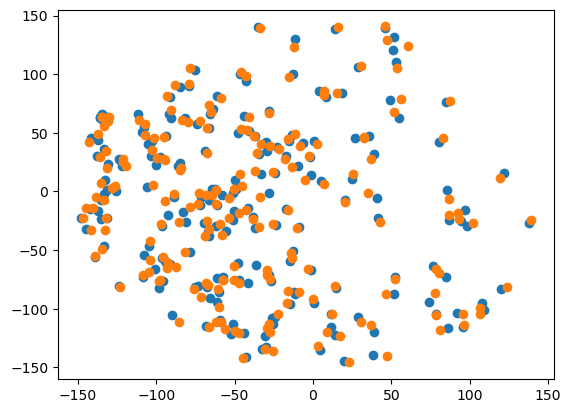

In [88]:
data_type = 'grad_away_1e7'
dopant_atoms_path = Path(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/final_datasets/grad_away_1e7/configs/vMB_gradient_away_output.txt')

dopants = np.loadtxt(dopant_atoms_path)

# --- Example usage with your file ---
dopants = np.loadtxt(dopant_atoms_path)   # shape (200,2)
R = 150.0          # <-- set to your disk radius
r_norm = np.sqrt(np.pi*R**2 / 200)
R_sc = R / r_norm
sigma = 3     # <-- noise strength (std dev)

dopants_noisy = add_noise_project_to_disk(dopants, sigma=sigma, R=R, seed=0)

plt.scatter(*dopants_noisy.T)
plt.scatter(*dopants.T)
# or:
# dopants_noisy = add_noise_resample_in_disk(dopants, sigma=sigma, R=R, seed=0)

# save if you want
# np.savetxt("vMB_gradient_away_output_noisy.txt", dopants_noisy)

## topK optimal solutions (BO)

tensor([ 1.5000, -0.2351, -0.0352, -1.5000, -1.1282, -1.5000])
tensor([-0.8273, -1.4251, -1.5000, -1.1749, -0.2155,  0.5264])
tensor([ 1.1731,  0.1928, -0.5679, -0.7370,  1.5000,  1.5000])
tensor([ 0.7027,  0.2550, -1.3838, -1.2390,  0.7243, -0.3420])
tensor([ 1.5000,  0.3304, -0.3635, -0.1137,  0.6474,  1.5000])
tensor([ 1.5000, -0.6168, -0.6085, -1.5000,  0.5008, -1.5000])
tensor([ 1.5000, -0.7797, -0.7852, -1.5000,  0.7613, -1.5000])
tensor([ 0.8222, -1.5000,  0.2840, -1.5000, -1.1101, -0.9049])
tensor([ 0.2140, -0.4008, -1.5000, -1.5000, -0.8316, -1.5000])
tensor([ 0.3718, -1.5000, -1.5000, -0.2847,  1.5000, -0.7320])
tensor([ 0.4825, -1.5000, -1.5000, -1.5000, -0.4310, -1.5000])
tensor([ 1.5000, -0.4155, -0.3587,  0.4445, -0.1701,  1.5000])
tensor([-0.6515, -1.5000, -1.5000, -1.5000, -0.2758, -1.5000])
tensor([ 1.5000, -1.5000, -0.4578, -1.5000,  1.5000, -1.5000])
tensor([ 0.2724, -1.5000, -1.5000, -0.1159, -1.5000, -1.5000])
tensor([-0.1454, -1.5000, -1.5000, -1.5000,  0.0610, -1

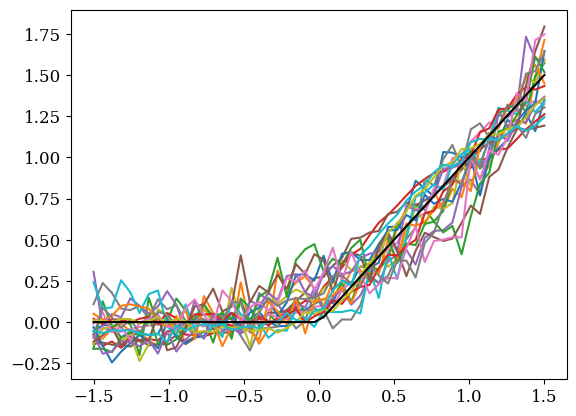

In [12]:
data_type = 'grad_away_1e7'

model_dir = f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/final_datasets/{data_type}/sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth'
state_dict = torch.load(model_dir, weights_only=False, map_location='cpu')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])
model = model.to(device)
model.eval()

func_type = 'ReLU'

input_idx_sim = 4
output_idx_sim = 0
control_indices = [0, 1, 2, 4, 5, 6]

n = 50
x = torch.linspace(-1.5, 1.5, n)
if func_type == 'Parabola':
    y_tgt = x ** 2
if func_type == 'ReLU':
    m = nn.ReLU()
    y_tgt = m(x)

sm_mse = []
kmc_mse = []

top_K_num = 20
fig, ax = plt.subplots()
for k in range(top_K_num):
    data = np.load(f'/home/hd/hd_hd/hd_gy283/kmc_project/workspaces/my_data_recover/1d_funcs_BO_mse/{data_type}_{func_type}_topK/bo_mse_func_type={func_type}_data_type={data_type}_topk={k}.npz')
    I_out = data['current']*1e21
    controls = torch.from_numpy(np.delete(data['control'], obj=[output_idx_sim, input_idx_sim], axis=0)).float()
    print(controls)
    """input_tensor = torch.zeros(n, len(control_indices) + 1)
    input_tensor[:, control_indices] = controls.expand(n, -1)
    input_tensor[:, input_idx_sim-1] = x
    input_tensor = input_tensor.to(device)
    with torch.no_grad():
        y_sm = model(input_tensor).detach().cpu().numpy().squeeze()"""
    
    a_kmc, b_kmc, y_aff_kmc = fit_affine_to_target(torch.from_numpy(I_out), y_tgt)
    """a_sm, b_sm, y_aff_sm = fit_affine_to_target(y_sm, y_tgt)

    sm_mse.append(np.mean((y_aff_sm - y_tgt)**2))"""
    kmc_mse.append(np.mean((y_aff_kmc.numpy() - y_tgt.numpy())**2))
    
    ax.plot(np.linspace(-1.5, 1.5, I_out.shape[0]), y_aff_kmc)

ax.plot(x, y_tgt, color='k', zorder=10)

kmc_mse = np.array(kmc_mse)
df = pd.read_csv(
    f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_BO_mse/bayes_opt_affine_data_type={data_type}'
    f'_input_idx=3_func_type={func_type}_lambda_1=0.0__lambda_2=1.0_c_range=1.5.csv'
)
topk = df.nlargest(top_K_num, "target").reset_index(drop=True)
loss_sm = (-topk["target"]).to_numpy()
print(loss_sm)

In [14]:
# controls from CSV "best" row
x_cols = [f"x{i}" for i in range(6)]
print(topk.loc[0, x_cols].to_numpy())

# controls stored in simulation file topk=0
data = np.load(f'/home/hd/hd_hd/hd_gy283/kmc_project/workspaces/my_data_recover/1d_funcs_BO_mse/{data_type}_{func_type}_topK/bo_mse_func_type={func_type}_data_type={data_type}_topk=0.npz')
controls = np.delete(data["control"], [output_idx_sim, input_idx_sim])
print(controls)

[ 1.5        -0.23505762 -0.03524683 -1.5        -1.12821024 -1.5       ]
[ 1.5        -0.23505762 -0.03524683 -1.5        -1.12821024 -1.5       ]


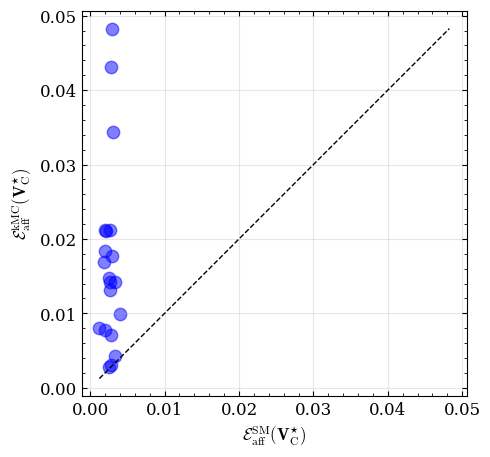

In [15]:
# --- transfer plot ---
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(loss_sm, kmc_mse, s=80, fc='b', alpha=0.5, ec='b')

mn = min(loss_sm.min(), kmc_mse.min())
mx = max(loss_sm.max(), kmc_mse.max())
ax.plot([mn, mx], [mn, mx], 'k--', lw=1)
ax.minorticks_on()
ax.set_box_aspect(1)
ax.tick_params(top=True, right=True, which='both')
ax.tick_params(direction='in', which='both')
ax.set_xlabel(r"$\mathcal{E}^{\mathrm{SM}}_{\mathrm{aff}}(\mathbf{V}^{\star}_{\mathrm{C}})$")
ax.set_ylabel(r"$\mathcal{E}^{\mathrm{kMC}}_{\mathrm{aff}}(\mathbf{V}^{\star}_{\mathrm{C}})$")
#ax.set_title(f"Transfer scatter: {data_type}, {func_type}")
ax.grid(alpha=0.3)
plt.show()